# make plots of days above compliance and ratio of exports to ndo

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmocean
import matplotlib.dates as mdates
from scipy.stats import linregress

In [2]:
#first load compliance by month, each row is a station, last row is x2
sta=['Chipps Island','Emmaton','Jersey Point','Franks Tract','CCWD','CCFB','X2']
df_compliance1=pd.read_csv('./x2_days_above_compliance_by_month_2026_04_14_baseline.csv')
df_compliance2=pd.read_csv('./x2_days_above_compliance_by_month_2026_04_14_dcp.csv')
df_compliance3=pd.read_csv('./x2_days_above_compliance_by_month_2026_04_14_cor.csv')
df_compliance3

,1,10,11,12
0,12.958333,31.000000,30.000000,31.000000
1,1.697917,23.239583,29.760417,0.354167
2,0.000000,31.000000,30.000000,21.927083
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,29.093750,9.166667,11.020833
5,0.000000,7.625000,0.000000,0.000000
6,3.000000,24.000000,30.000000,21.000000


In [3]:
for c in df_compliance1.columns:
    print(c)

1
10
11
12


In [4]:
#divide each column by the number of days in the month
df_compliance1norm=df_compliance1.copy()/31
df_compliance2norm=df_compliance2.copy()/31
df_compliance3norm=df_compliance3.copy()/31

#now correct the months that dont have 30 days
for c in df_compliance1norm.columns:
    if c in ['4','6','9','11']:
        #months w/ 30 days
        df_compliance1norm[c]=df_compliance1norm[c]*31/30
        df_compliance2norm[c]=df_compliance2norm[c]*31/30
        df_compliance3norm[c]=df_compliance3norm[c]*31/30
    elif c=='2':
        df_compliance1norm[c]=df_compliance1norm[c]*31/28 #assumes not a leap year
        df_compliance2norm[c]=df_compliance2norm[c]*31/30
        df_compliance3norm[c]=df_compliance3norm[c]*31/30
        
df_compliance3norm

# df_compliance1['1_norm']=df_compliance1['1']/31
# df_compliance2['1_norm']=df_compliance2['1']/31
# df_compliance3['1_norm']=df_compliance3['1']/31

# df_compliance1['10_norm']=df_compliance1['10']/31
# df_compliance2['10_norm']=df_compliance2['10']/31
# df_compliance3['10_norm']=df_compliance3['10']/31

# df_compliance1['11_norm']=df_compliance1['11']/30
# df_compliance2['11_norm']=df_compliance2['11']/30
# df_compliance3['11_norm']=df_compliance3['11']/30

# df_compliance1['12_norm']=df_compliance1['12']/30
# df_compliance2['12_norm']=df_compliance2['12']/30
# df_compliance3['12_norm']=df_compliance3['12']/30

,1,10,11,12
0,0.418011,1.000000,1.000000,1.000000
1,0.054772,0.749664,0.992014,0.011425
2,0.000000,1.000000,1.000000,0.707325
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.938508,0.305556,0.355511
5,0.000000,0.245968,0.000000,0.000000
6,0.096774,0.774194,1.000000,0.677419


In [5]:
df_compliance1norm

,1,10,11,12
0,0.418011,1.000000,1.000000,1.000000
1,0.054772,0.749664,0.992014,0.011425
2,0.000000,1.000000,1.000000,0.707325
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.938508,0.305556,0.355511
5,0.000000,0.245968,0.000000,0.000000
6,0.193548,0.967742,1.000000,0.774194


In [6]:
#each row is a scenario, order is baseline,dcp,cor
scen=['Baseline','DCP','CoR']
df_ratio=pd.read_csv('./ratio_exports_all_scenarios_2026_04_14.csv')
df_ratio

,1,10,11,12
0,0.287372,1.433236,0.601885,0.976476
1,0.494011,1.100239,1.290508,1.050079
2,0.158489,0.825969,0.827514,0.823855


(0, np.int64(0))
(0, np.int64(1))
(1, np.int64(0))
Skip Franks Tract
(1, np.int64(1))
(2, np.int64(0))
(2, np.int64(1))


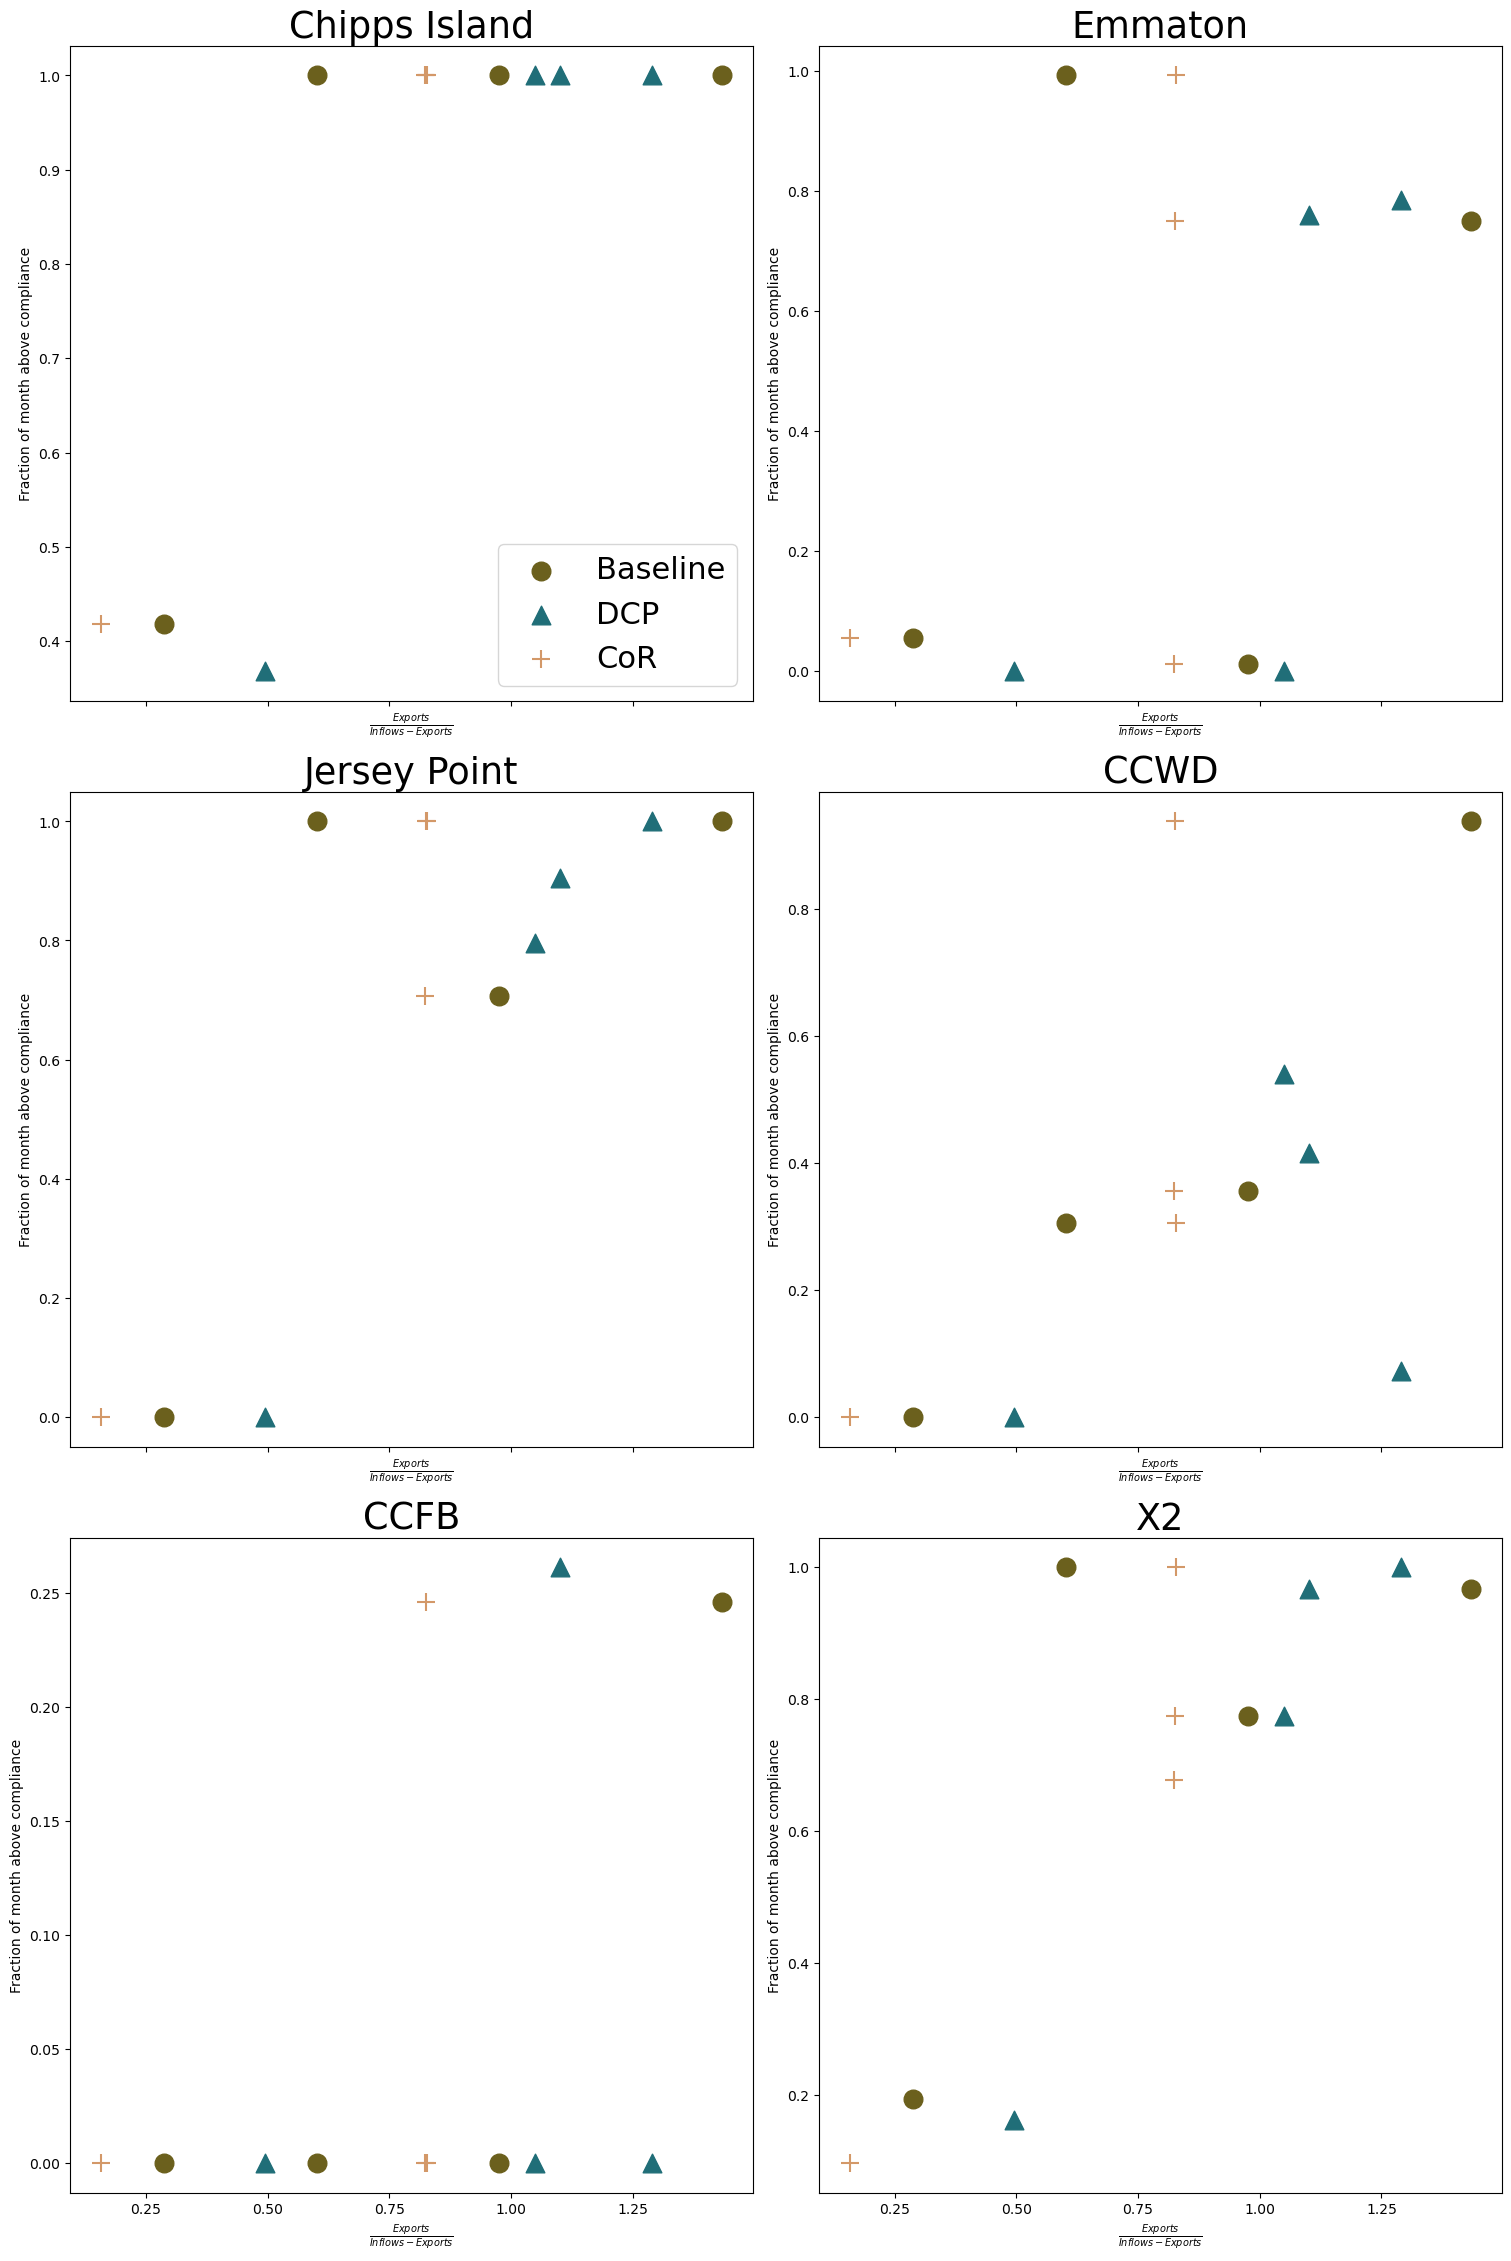

In [7]:
# make 6 tiled plots of fraction days above compliance versus export fraction, skip franks tract

fig, ax = plt.subplots(3,2,figsize=(15,22.5),sharex=True,layout='constrained',label='compliance')
mpl.rcParams.update({'font.size': 22})
# ax.grid(alpha=0.5)
for idx in np.arange(0,len(sta)):
    if idx>3:
        s=(int(np.floor((idx-1)/2)),(idx-1) % 2) 
    elif idx==3:
        idx=np.nan
        print('Skip Franks Tract')
    else:
        s=(int(np.floor(idx/2)),idx % 2)
    if ~np.isnan(idx):
        print(s)
        #for each scenario, plot the export fraction on the x axis and fraction of days above compliance on y 
        count=0
        for c in df_ratio.columns:
            #iterate through the months
            #scenario 1
            col=cmocean.cm.tarn(1/6)
            ax[s].scatter(df_ratio.loc[0,c],df_compliance1norm.loc[idx,c],color=col,label=scen[0],s=180)
            #scenario 2
            col=cmocean.cm.tarn(10/12)
            ax[s].scatter(df_ratio.loc[1,c],df_compliance2norm.loc[idx,c],color=col,label=scen[1],marker='^',s=180)
            #scenario 3
            col=cmocean.cm.tarn(2/6)
            ax[s].scatter(df_ratio.loc[2,c],df_compliance3norm.loc[idx,c],color=col,label=scen[2],marker='+',s=180)
            if idx==0 and count==0:
                ax[s].legend()#frameon=False)
            count=count+1

        ax[s].set_xlabel(r'$\frac{Exports}{Inflows-Exports}$')
        ax[s].set_ylabel('Fraction of month above compliance')
        
        ax[s].set_title(sta[idx])
        
        
# ax[1,0].set_ylabel('Fraction of month above compliance')
# ax[1,1].set_ylabel('Fraction of month above compliance')
#fig.savefig('/home/jisrael/Savio_scratch_back_up/Plotting/expanse/ch_3_figures/compliance_correlation_noR2.png')

In [8]:
from sklearn.metrics import r2_score
from scipy.stats import pearsonr, spearmanr

In [9]:
def addr2(x,y,string,s):
    minx=np.min(x)
    maxy=np.max(y)
    #r2=r2_score(x,y)
    #pr, _=pearsonr(x,y)
    sr, _ =spearmanr(x,y)
    #plt.annotate("Pearson R = {:.3f}".format(pr), (minx, 1.1*maxy))
    ax[s].annotate(String + " Spearman R = {:.3f}".format(sr), (minx, 1.05*maxy))
    ax[s].xlim(minx-0.05*np.max(x),1.05*np.max(x))
    ax[s].ylim(np.min(y)-0.05*np.max(y),1.15*maxy)
    return

(0, np.int64(0))
(0, np.int64(1))
(1, np.int64(0))
Skip Franks Tract
(1, np.int64(1))
(2, np.int64(0))
(2, np.int64(1))


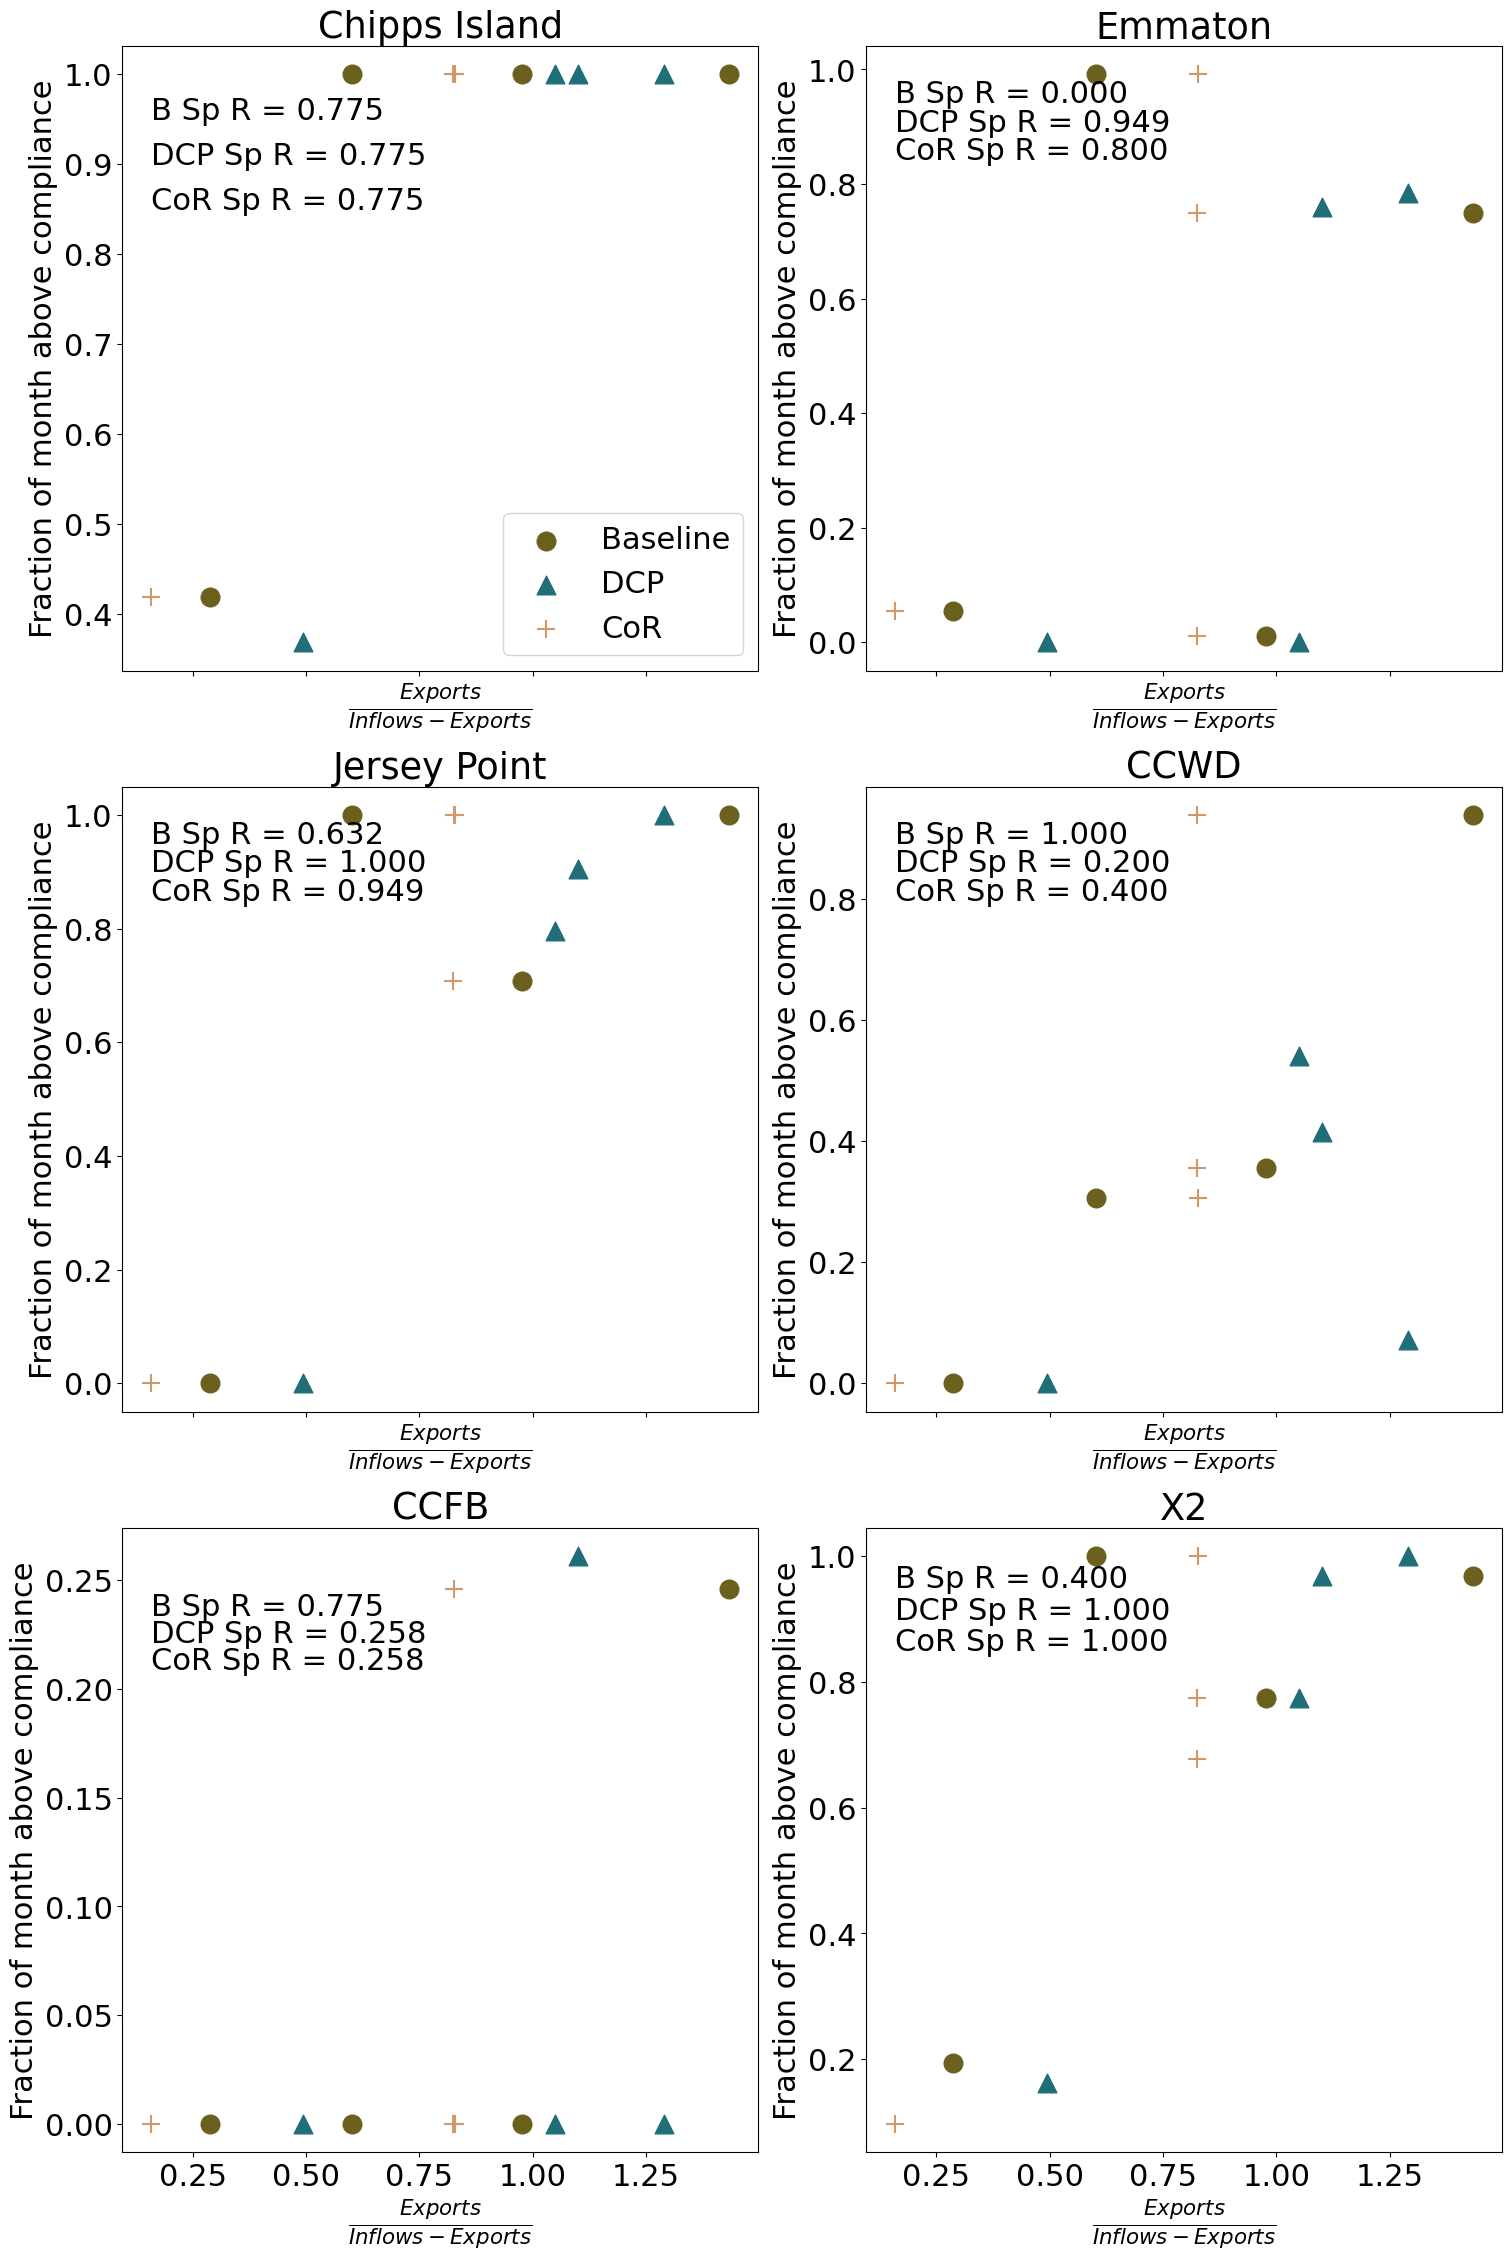

In [11]:
# make 6 tiled plots of fraction days above compliance versus export fraction, skip franks tract

fig, ax = plt.subplots(3,2,figsize=(15,22.5),sharex=True,layout='constrained',label='compliance')
mpl.rcParams.update({'font.size': 22})
# ax.grid(alpha=0.5)
for idx in np.arange(0,len(sta)):
    if idx>3:
        s=(int(np.floor((idx-1)/2)),(idx-1) % 2) 
    elif idx==3:
        idx=np.nan
        print('Skip Franks Tract')
    else:
        s=(int(np.floor(idx/2)),idx % 2)
    if ~np.isnan(idx):
        print(s)
        #for each scenario, plot the export fraction on the x axis and fraction of days above compliance on y 
        count=0
        #for computing the correlation coefficient, need to collect all the x and ys to pass to function
        x1=df_ratio.loc[0,:]
        y1=df_compliance1norm.loc[idx,:]
        sr1, _ =spearmanr(x1,y1)
        x2=df_ratio.loc[1,:]
        y2=df_compliance2norm.loc[idx,:]
        sr2, _ =spearmanr(x2,y2)
        x3=df_ratio.loc[2,:]
        y3=df_compliance3norm.loc[idx,:]
        sr3, _ =spearmanr(x3,y3)
        minx=np.min(x3)
        maxy=np.max(y1)
        col=cmocean.cm.tarn(1/6)
        ax[s].scatter(x1,y1,color=col,label=scen[0],s=180)
        ax[s].annotate("B Sp R = {:.3f}".format(sr1), (minx,maxy*0.95))
        # ax[s].xlim(minx-0.05*np.max(x),1.05*np.max(x))
        # ax[s].ylim(np.min(y)-0.05*np.max(y),1.15*maxy)
        col=cmocean.cm.tarn(10/12)
        ax[s].scatter(x2,y2,color=col,label=scen[1],marker='^',s=180)
        ax[s].annotate("DCP Sp R = {:.3f}".format(sr2), (minx,maxy*0.9))
        col=cmocean.cm.tarn(2/6)
        ax[s].scatter(x3,y3,color=col,label=scen[2],marker='+',s=180)
        ax[s].annotate("CoR Sp R = {:.3f}".format(sr3), (minx,maxy*0.85))
        if idx==0 and count==0:
            ax[s].legend()#frameon=False)
            count=count+1
            
        ax[s].set_xlabel(r'$\frac{Exports}{Inflows-Exports}$')
        ax[s].set_ylabel('Fraction of month above compliance')
        
        ax[s].set_title(sta[idx])
plt.show()        
        
# ax[1,0].set_ylabel('Fraction of month above compliance')
# ax[1,1].set_ylabel('Fraction of month above compliance')
fig.savefig('/home/jisrael/Savio_scratch_back_up/Plotting/expanse/ch_3_figures/compliance_correlation_wspearmanR2.png')

(0, np.int64(0))
(0, np.int64(1))
(1, np.int64(0))
Skip Franks Tract
(1, np.int64(1))
(2, np.int64(0))
(2, np.int64(1))


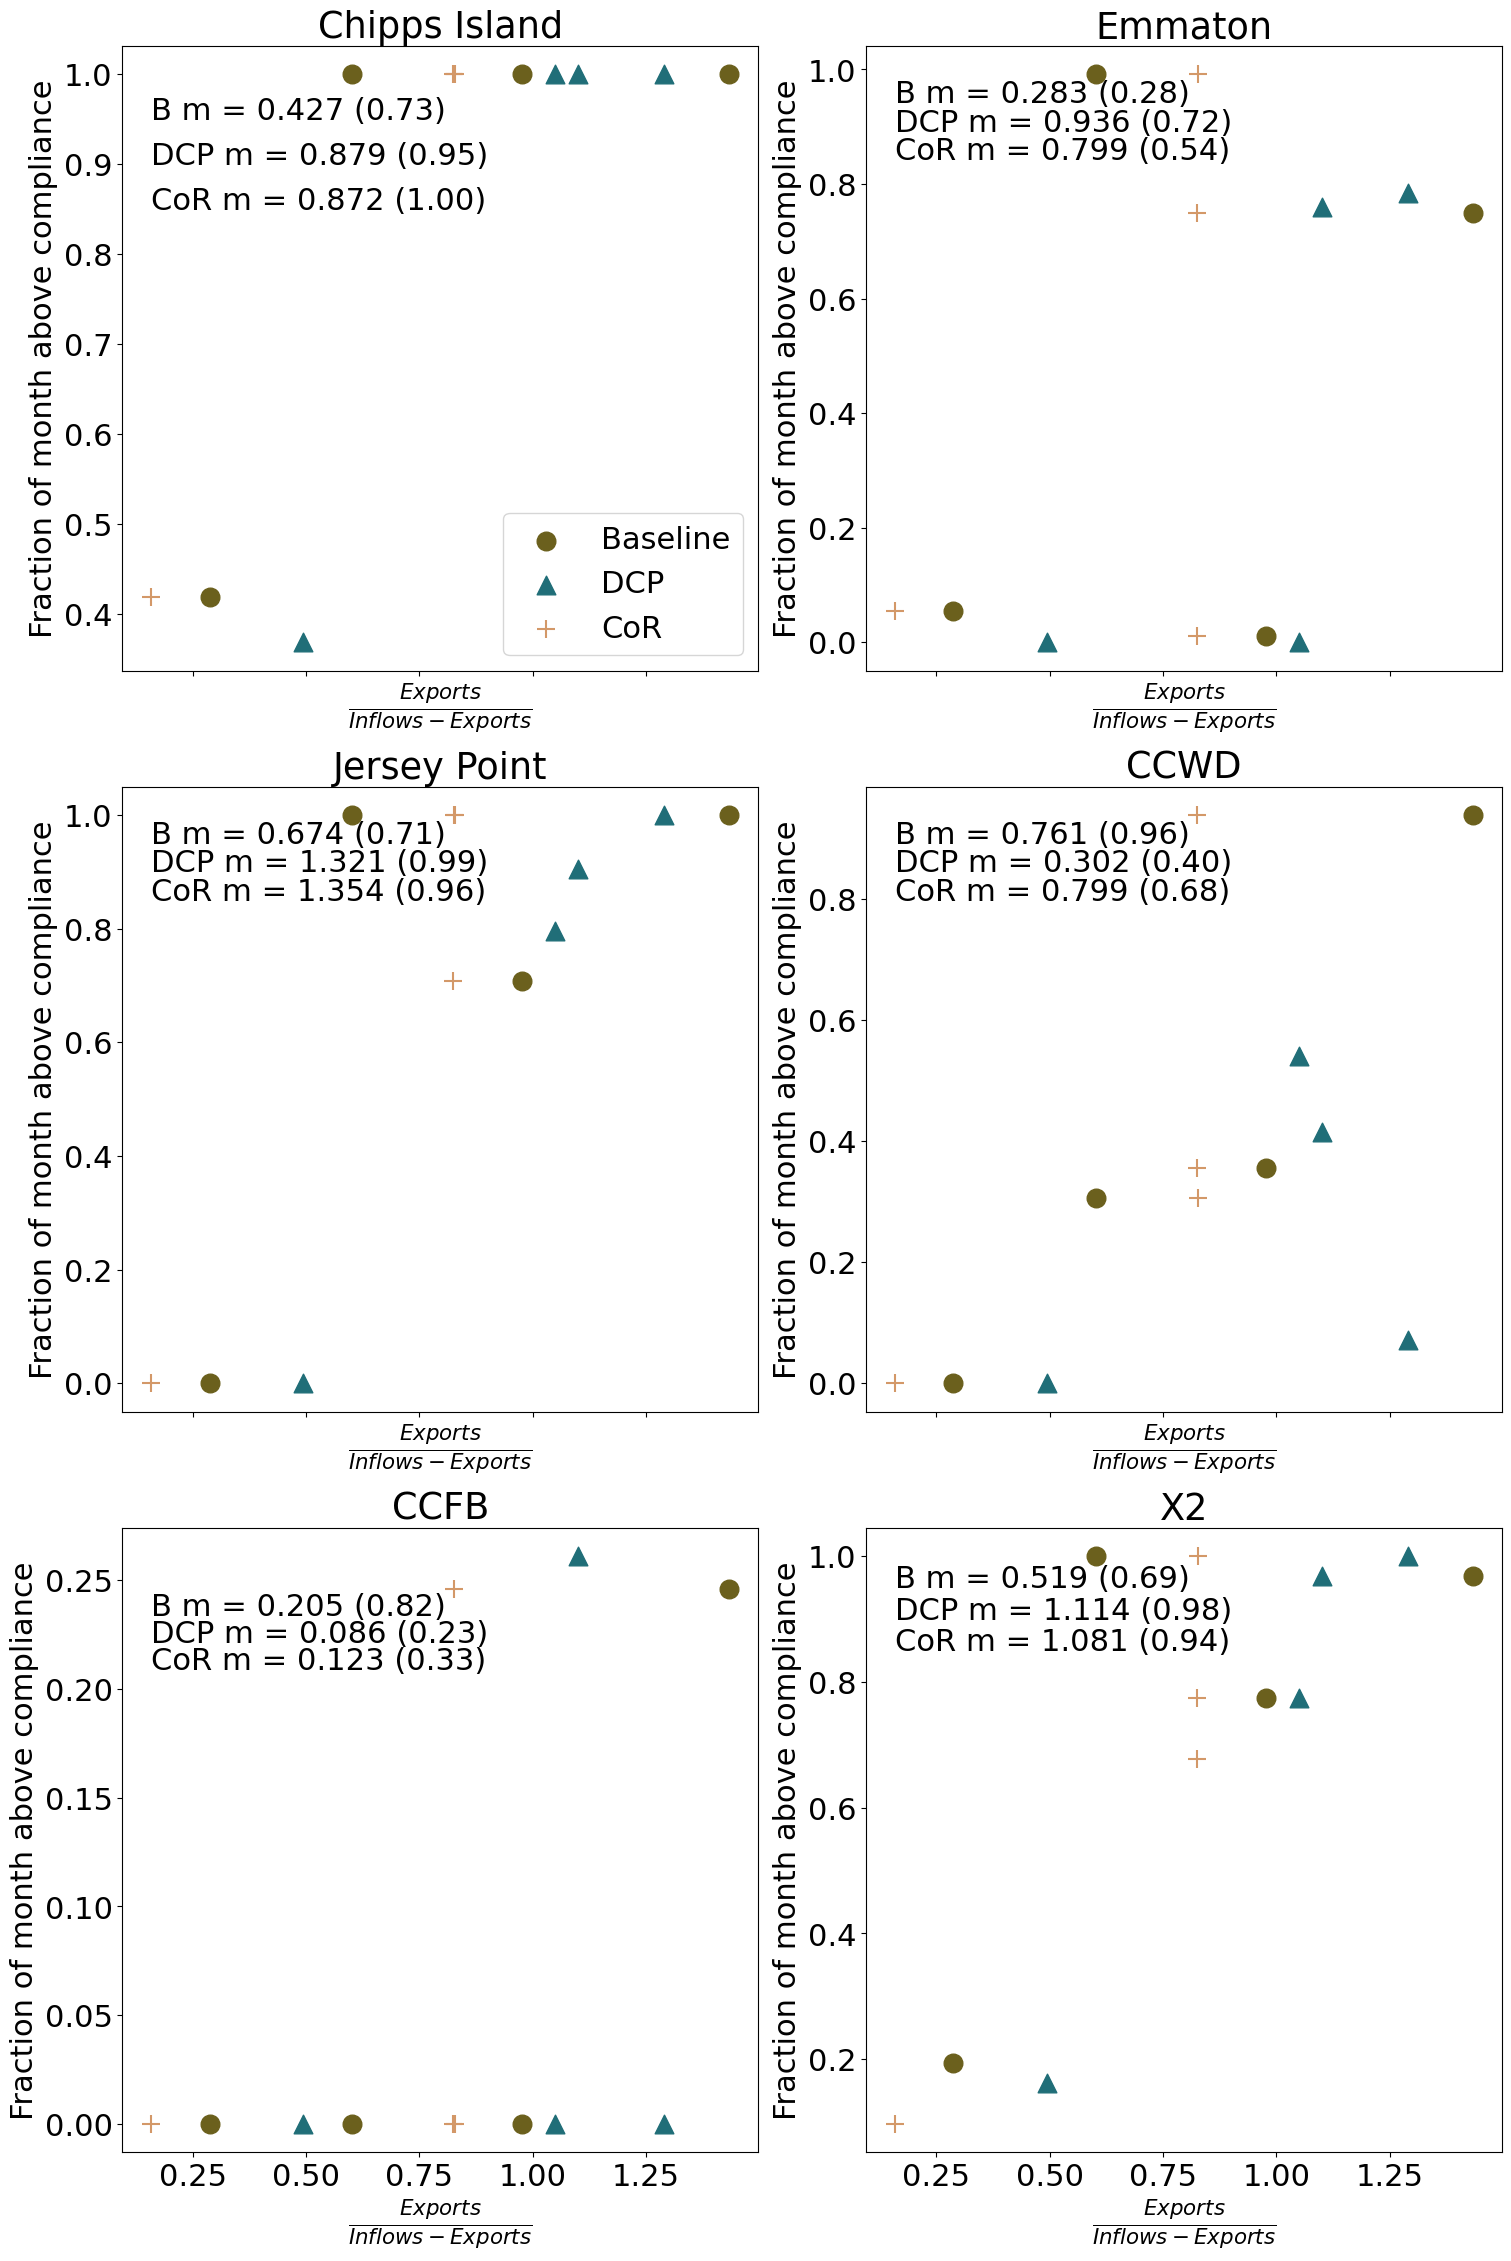

In [12]:
# Instead of spearman r add slope and r2
# make 6 tiled plots of fraction days above compliance versus export fraction, skip franks tract

fig, ax = plt.subplots(3,2,figsize=(15,22.5),sharex=True,layout='constrained',label='compliance')
mpl.rcParams.update({'font.size': 22})
# ax.grid(alpha=0.5)
for idx in np.arange(0,len(sta)):
    if idx>3:
        s=(int(np.floor((idx-1)/2)),(idx-1) % 2) 
    elif idx==3:
        idx=np.nan
        print('Skip Franks Tract')
    else:
        s=(int(np.floor(idx/2)),idx % 2)
    if ~np.isnan(idx):
        print(s)
        #for each scenario, plot the export fraction on the x axis and fraction of days above compliance on y 
        count=0
        #for computing the correlation coefficient, need to collect all the x and ys to pass to function
        x1=df_ratio.loc[0,:]
        y1=df_compliance1norm.loc[idx,:]
        result1 = linregress(x1,y1)
        x2=df_ratio.loc[1,:]
        y2=df_compliance2norm.loc[idx,:]
        result2 = linregress(x2,y2)
        x3=df_ratio.loc[2,:]
        y3=df_compliance3norm.loc[idx,:]
        result3 = linregress(x3,y3)
        minx=np.min(x3)
        maxy=np.max(y1)
        col=cmocean.cm.tarn(1/6)
        ax[s].scatter(x1,y1,color=col,label=scen[0],s=180)
        ax[s].annotate("B m = {:.3f} ({:.2f})".format(result1.slope,result1.rvalue), (minx,maxy*0.95))
        # ax[s].xlim(minx-0.05*np.max(x),1.05*np.max(x))
        # ax[s].ylim(np.min(y)-0.05*np.max(y),1.15*maxy)
        col=cmocean.cm.tarn(10/12)
        ax[s].scatter(x2,y2,color=col,label=scen[1],marker='^',s=180)
        ax[s].annotate("DCP m = {:.3f} ({:.2f})".format(result2.slope,result2.rvalue), (minx,maxy*0.90))
        col=cmocean.cm.tarn(2/6)
        ax[s].scatter(x3,y3,color=col,label=scen[2],marker='+',s=180)
        ax[s].annotate("CoR m = {:.3f} ({:.2f})".format(result3.slope,result3.rvalue), (minx,maxy*0.85))
        if idx==0 and count==0:
            ax[s].legend()#frameon=False)
            count=count+1
            
        ax[s].set_xlabel(r'$\frac{Exports}{Inflows-Exports}$')
        ax[s].set_ylabel('Fraction of month above compliance')
        
        ax[s].set_title(sta[idx])
plt.show()        
        
# ax[1,0].set_ylabel('Fraction of month above compliance')
# ax[1,1].set_ylabel('Fraction of month above compliance')
fig.savefig('/home/jisrael/Savio_scratch_back_up/Plotting/expanse/ch_3_figures/compliance_correlation_wslope.png')